# Figure 5 Compare Models


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from violmulti.data.dataset_loader import DatasetLoader
from violmulti.experiments.experiment import load_experiment
from violmulti.utils.violation_iti import *
from violmulti.visualizations.model_visualizer import *
from violmulti.models.linear_regression import *
import config as c
from violmulti.data import ANIMAL_IDS
from violmulti.features.exp_filter import ExpFilter
from violmulti.features.design_matrix_generator_PWM import *

sns.set_context("talk")

%load_ext autoreload
%autoreload 2

DATA_PATH = "/Users/jessbreda/Desktop/github/violations-multinomial/notebooks/publication/data/model_fits"

# multi_compare_exp = "2025_07_22_fig5_compare_intrxs_rs47.pkl"
multi_compare_exp = "2025_07_22_fig5_compare_multi_intrxs_rs47.pkl"

binary_compare_exp ="2025_07_22_fig5_compare_to_binary_rs47.pkl"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:

ORDER = [
    "base",
    "prev_viol_binary",
    "prev_viol_filtered",
    "prev_viol_binary_itrx",
    "prev_viol_filtered_itrx",
]
LABELS = [
    "Baseline",
    "+ Binary\nViolation History",
    "+ Filtered\nViolation History",
    "+ Binary\nViolation History\n& Stim Intrxs",
    "+ Filtered\nViolation History\n& Stim Intrxs",
]
COLORS = [
    "gray",
    "#93c47d",
    "darkgreen",
    "orange",
    "#ce8641",
]

# B Compare Multi


In [13]:
mvcm = ModelVisualizerCompare(load_experiment(multi_compare_exp, save_path=c.MODEL_FITS_PATH))


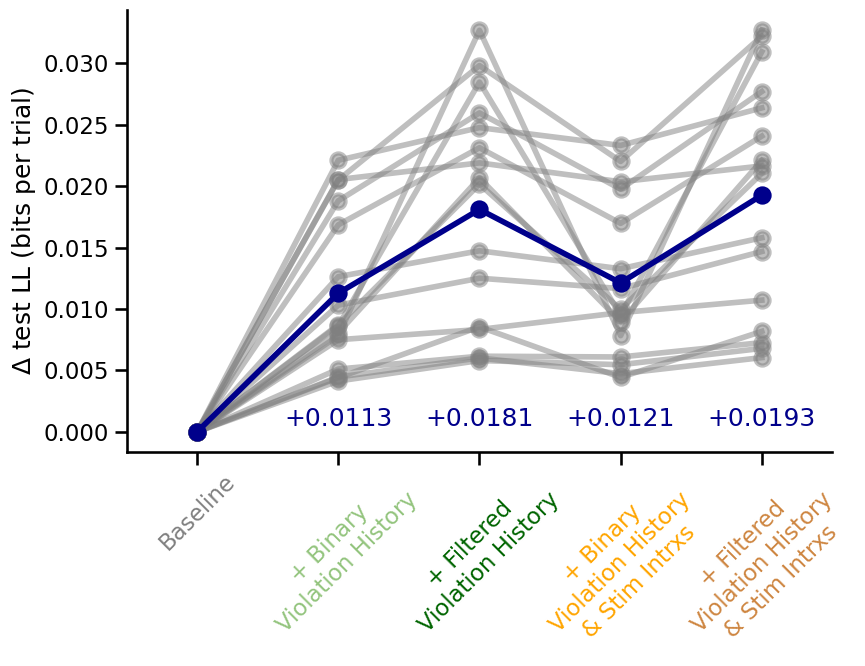

In [14]:
fig, ax = plt.subplots(figsize=(9,7
                                ))
sns.despine()
mvcm.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
mvcm.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
    annotate=True,
    y_annotate=0.0005,
    color_annotate=c.MODEL_COMPARE_COLOR,
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=45)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)
ax.legend().remove()
ax.set(xlabel="", title="")

# save fig
plt.tight_layout()
plt.savefig("figures/fig5_multi_compare_prev_viol_and_intrxs.png", dpi=300, bbox_inches="tight")

In [15]:
bpt = mvcm.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])


,mean,std
model_name,,
base,0.000000,0.000000
null,-1.777418,0.070941
prev_viol_binary,0.011287,0.006384
prev_viol_binary_itrx,0.012127,0.006400
prev_viol_filtered,0.018103,0.009250
prev_viol_filtered_itrx,0.019265,0.009485


## Base vs Intrx Filtered


In [16]:

mvcm.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1046: RuntimeWarning: overflow encountered in scalar power
  overall_ratio = 2 ** overall_diff_bits
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1050: RuntimeWarning: overflow encountered in scalar power
  if np.isinf(2 ** overall_diff_bits):


{'overall_ratio': inf, 'log10_overall_ratio': 2325.2087890234975}

In [17]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 2.1161639611893208e+145,
 'log10_geometric_mean_ratio': 145.32554931396857}

> On average, each animal's test data is $10^{145}$ times more likely under the previous violation filtered model


## Filtered vs Intrx Filtered


In [18]:

mvcm.compute_overall_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 7.50904365015618e+140,
 'log10_overall_ratio': 140.875584628894}

In [19]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 637858047.7298766,
 'log10_geometric_mean_ratio': 8.804724039305873}

> On average, each animal's test data is $10^{8}$ times more likely under the previous violation filtered model


In [20]:
bpt = mvcm.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])


,mean,std
model_name,,
base,0.000000,0.000000
null,-1.777418,0.070941
prev_viol_binary,0.011287,0.006384
prev_viol_binary_itrx,0.012127,0.006400
prev_viol_filtered,0.018103,0.009250
prev_viol_filtered_itrx,0.019265,0.009485


## Base vs Intrx Filtered


In [21]:

mvcm.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1046: RuntimeWarning: overflow encountered in scalar power
  overall_ratio = 2 ** overall_diff_bits
/Users/jessbreda/Desktop/github/violations-multinomial/src/violmulti/visualizations/model_visualizer.py:1050: RuntimeWarning: overflow encountered in scalar power
  if np.isinf(2 ** overall_diff_bits):


{'overall_ratio': inf, 'log10_overall_ratio': 2325.2087890234975}

In [22]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 2.1161639611893208e+145,
 'log10_geometric_mean_ratio': 145.32554931396857}

> On average, each animal's test data is $10^{145}$ times more likely under the previous violation filtered model


## Filtered vs Intrx Filtered


In [23]:

mvcm.compute_overall_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 7.50904365015618e+140,
 'log10_overall_ratio': 140.875584628894}

In [24]:

mvcm.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 637858047.7298766,
 'log10_geometric_mean_ratio': 8.804724039305873}

> On average, each animal's test data is $10^{8}$ times more likely under the previous violation filtered model


# D Compare Binary


In [26]:
mvcb = ModelVisualizerCompare(load_experiment(binary_compare_exp, save_path=c.MODEL_FITS_PATH))

In [34]:
ORDER

['base',
 'prev_viol_binary',
 'prev_viol_filtered',
 'prev_viol_binary_itrx',
 'prev_viol_filtered_itrx']

In [35]:
LABELS

['Baseline',
 '+ Binary\nViolation History',
 '+ Filtered\nViolation History',
 '+ Binary\nViolation History\n& Stim Intrxs',
 '+ Filtered\nViolation History\n& Stim Intrxs']

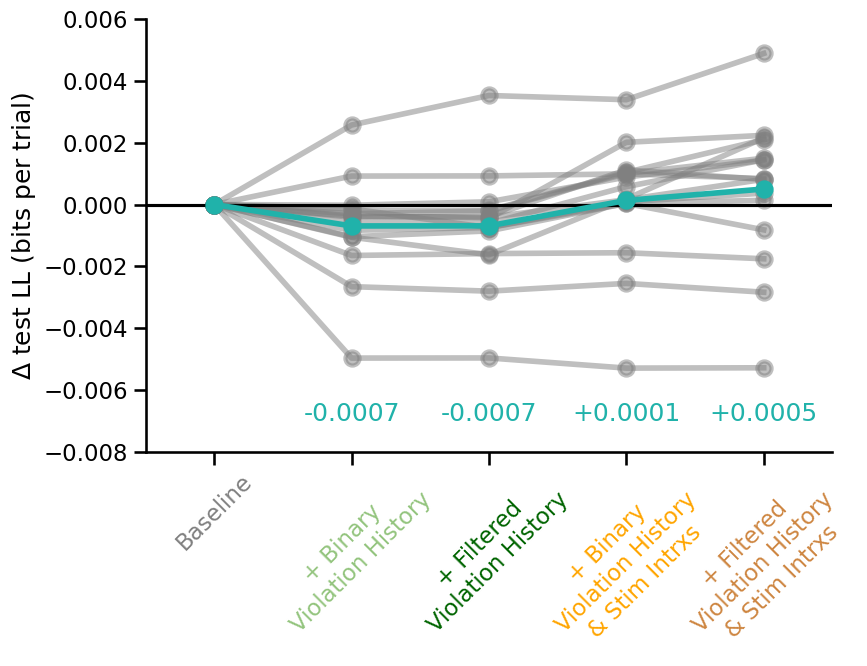

In [36]:
fig, ax = plt.subplots(figsize=(9,7
                                ))
sns.despine()
mvcb.plot_model_comparison(
    hue="animal_id",
    ax=ax,
    order=ORDER,
    palette=["gray"] * 16,
    alpha = 0.5,
    y="bits_per_trial_relative_to_base"
)
ax.axhline(y=0, color="black")
mvcb.plot_model_comparison(
    ax=ax,
    order=ORDER,
    color=c.BINARY_MODEL_COMPARE_COLOR,
    errorbar=None,
    y="bits_per_trial_relative_to_base",
    ylabel="$\Delta$ test LL (bits per trial)",
    annotate=True,
    y_annotate=-0.007,
    color_annotate=c.BINARY_MODEL_COMPARE_COLOR,
)
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS, rotation=45)
tick_labels = ax.get_xticklabels()
for label, color in zip(tick_labels, COLORS):
    label.set_color(color)
ax.legend().remove()
ax.set(xlabel="", title="", ylim=(-0.008, 0.006))

# save fig
plt.tight_layout()
plt.savefig("figures/fig5_binary_compare_prev_viol_and_intrxs.png", dpi=300, bbox_inches="tight")

In [28]:
bpt = mvcb.compute_bits_per_trial_df()

bpt.groupby("model_name").bits_per_trial_relative_to_base.agg(["mean", "std"])


,mean,std
model_name,,
base,0.000000,0.000000
null,-1.369610,0.084161
prev_viol_binary,-0.000692,0.001592
prev_viol_binary_itrx,0.000133,0.001961
prev_viol_filtered,-0.000690,0.001753
prev_viol_filtered_itrx,0.000502,0.002340


## Base vs Intrx Filtered


In [29]:

mvcb.compute_overall_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 9.985879917246083e+76,
 'log10_overall_ratio': 76.99938633924853}

In [30]:

mvcb.compute_geometric_mean_ll_ratio(base_model_name="base", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 64932.428534559906,
 'log10_geometric_mean_ratio': 4.812461646203032}

> On average, each animal's test data is $10^{6}$ times more likely under the previous violation filtered model


## Filtered vs Intrx Filtered


In [31]:

mvcb.compute_overall_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'overall_ratio': 7.467807031706151e+110,
 'log10_overall_ratio': 110.87319308724331}

In [32]:

mvcb.compute_geometric_mean_ll_ratio(base_model_name="prev_viol_filtered", new_model_name="prev_viol_filtered_itrx")


{'geometric_mean_ratio': 8503046.771650728,
 'log10_geometric_mean_ratio': 6.929574567952705}

> On average, each animal's test data is $10^{8}$ times more likely under the previous violation filtered model
